# Diagnóstico de Doenças da Tireoide com Machine Learning

## 1. Contexto do Projeto

Este projeto faz parte do módulo final do curso Profissão: Cientista de Dados, no qual o objetivo é simular uma situação real de mercado. Entre os cases disponíveis, foi escolhido o problema relacionado ao diagnóstico de doenças da tireoide, utilizando uma base de dados com informações clínicas, laboratoriais e históricas de pacientes.

A proposta é desenvolver uma solução de Machine Learning capaz de auxiliar na classificação do diagnóstico a partir dos atributos disponíveis na base. O projeto contempla as principais etapas de um projeto de Ciência de Dados: entendimento do problema, preparação dos dados, análise exploratória, modelagem, avaliação dos resultados e comunicação dos principais achados.

## 2. Entendimento do Problema

O problema apresentado pelo stakeholder está relacionado à área médica, mais especificamente ao diagnóstico de condições associadas à tireoide. O objetivo é construir um modelo de classificação capaz de identificar padrões nos dados dos pacientes e apoiar a tomada de decisão clínica.

Como se trata de um problema de saúde, a avaliação do modelo deve considerar não apenas a acurácia, mas também métricas como precisão, recall e F1-score. Em especial, o recall é importante porque indica a capacidade do modelo de identificar corretamente os casos positivos, reduzindo o risco de deixar pacientes com possível condição clínica sem sinalização.

A variável-alvo do projeto será analisada a partir da coluna de diagnóstico presente na base de dados. As demais variáveis serão utilizadas como atributos explicativos, incluindo informações demográficas, histórico médico, uso de medicamentos, sintomas e resultados laboratoriais.

## 3. Importação das Bibliotecas

In [1]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Modelos de classificação
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Métricas de avaliação
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Configurações gerais
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

sns.set_theme(style='whitegrid')

## 4. Carregamento da Base de Dados

In [2]:
df = pd.read_csv('Base_M43_Pratique_Hypothyroid.csv')
df.head()

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,query hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH measured,TSH,T3 measured,T3,TT4 measured,TT4,T4U measured,T4U,FTI measured,FTI,TBG measured,TBG,referral source,binaryClass
0,41,F,f,f,f,f,f,f,f,f,f,f,f,f,f,f,t,1.3,t,2.5,t,125,t,1.14,t,109,f,?,SVHC,P
1,23,F,f,f,f,f,f,f,f,f,f,f,f,f,f,f,t,4.1,t,2,t,102,f,?,f,?,f,?,other,P
2,46,M,f,f,f,f,f,f,f,f,f,f,f,f,f,f,t,0.98,f,?,t,109,t,0.91,t,120,f,?,other,P
3,70,F,t,f,f,f,f,f,f,f,f,f,f,f,f,f,t,0.16,t,1.9,t,175,f,?,f,?,f,?,other,P
4,70,F,f,f,f,f,f,f,f,f,f,f,f,f,f,f,t,0.72,t,1.2,t,61,t,0.87,t,70,f,?,SVI,P


## 5. Análise Inicial dos Dados

In [3]:
# Dimensão da base
df.shape

(3772, 30)

In [4]:
# Informações gerais
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3772 entries, 0 to 3771
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   age                        3772 non-null   str  
 1   sex                        3772 non-null   str  
 2   on thyroxine               3772 non-null   str  
 3   query on thyroxine         3772 non-null   str  
 4   on antithyroid medication  3772 non-null   str  
 5   sick                       3772 non-null   str  
 6   pregnant                   3772 non-null   str  
 7   thyroid surgery            3772 non-null   str  
 8   I131 treatment             3772 non-null   str  
 9   query hypothyroid          3772 non-null   str  
 10  query hyperthyroid         3772 non-null   str  
 11  lithium                    3772 non-null   str  
 12  goitre                     3772 non-null   str  
 13  tumor                      3772 non-null   str  
 14  hypopituitary              3772 non

In [5]:
# Visualizando os nomes das colunas
df.columns

Index(['age', 'sex', 'on thyroxine', 'query on thyroxine',
       'on antithyroid medication', 'sick', 'pregnant', 'thyroid surgery',
       'I131 treatment', 'query hypothyroid', 'query hyperthyroid', 'lithium',
       'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH measured', 'TSH',
       'T3 measured', 'T3', 'TT4 measured', 'TT4', 'T4U measured', 'T4U',
       'FTI measured', 'FTI', 'TBG measured', 'TBG', 'referral source',
       'binaryClass'],
      dtype='str')

In [6]:
# Resumo inicial da base
df.describe()

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,query hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH measured,TSH,T3 measured,T3,TT4 measured,TT4,T4U measured,T4U,FTI measured,FTI,TBG measured,TBG,referral source,binaryClass
count,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772
unique,94,3,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,288,2,70,2,242,2,147,2,235,1,1,5,2
top,59,F,f,f,f,f,f,f,f,f,f,f,f,f,f,f,t,?,t,?,t,?,t,?,t,?,f,?,other,P
freq,95,2480,3308,3722,3729,3625,3719,3719,3713,3538,3535,3754,3738,3676,3771,3588,3403,369,3003,769,3541,231,3385,387,3387,385,3772,3772,2201,3481


In [7]:
# Verificando valores nulos
df.isnull().sum().sort_values(ascending=False)

age                          0
sex                          0
on thyroxine                 0
query on thyroxine           0
on antithyroid medication    0
sick                         0
pregnant                     0
thyroid surgery              0
I131 treatment               0
query hypothyroid            0
query hyperthyroid           0
lithium                      0
goitre                       0
tumor                        0
hypopituitary                0
psych                        0
TSH measured                 0
TSH                          0
T3 measured                  0
T3                           0
TT4 measured                 0
TT4                          0
T4U measured                 0
T4U                          0
FTI measured                 0
FTI                          0
TBG measured                 0
TBG                          0
referral source              0
binaryClass                  0
dtype: int64

In [8]:
# Verificando possíveis valores ausentes representados por '?'
(df == '?').sum().sort_values(ascending=False)

TBG                          3772
T3                            769
T4U                           387
FTI                           385
TSH                           369
TT4                           231
sex                           150
age                             1
pregnant                        0
thyroid surgery                 0
on thyroxine                    0
query on thyroxine              0
on antithyroid medication       0
sick                            0
tumor                           0
goitre                          0
lithium                         0
query hyperthyroid              0
query hypothyroid               0
I131 treatment                  0
TSH measured                    0
hypopituitary                   0
TT4 measured                    0
T3 measured                     0
psych                           0
T4U measured                    0
FTI measured                    0
TBG measured                    0
referral source                 0
binaryClass   

A base possui 3.772 registros e 30 variáveis. Inicialmente, todas as colunas foram carregadas como texto (`str`), incluindo variáveis que representam valores numéricos, como idade e exames laboratoriais.

Embora o `df.info()` indique ausência de valores nulos, foi identificado que os valores faltantes estão representados pelo símbolo `"?"`. As colunas com maior quantidade de valores ausentes são `TBG`, `T3`, `T4U`, `FTI`, `TSH`, `TT4`, `sex` e `age`.

Dessa forma, será necessário substituir `"?"` por `NaN`, remover ou tratar colunas com muitos valores ausentes, converter as variáveis numéricas para o tipo adequado e preparar as variáveis categóricas para a modelagem.

Essa etapa é importante para compreender a estrutura da base, identificar inconsistências e planejar o tratamento necessário antes da construção dos modelos de Machine Learning.

## 6. Tratamento e Preparação dos Dados

In [9]:
# Criando uma cópia da base original
df_clean = df.copy()

In [10]:
# Substituindo valores '?' por NaN
df_clean = df_clean.replace('?', np.nan)

In [11]:
# Verificando novamente os valores ausentes após substituir '?'
df_clean.isnull().sum().sort_values(ascending=False)

TBG                          3772
T3                            769
T4U                           387
FTI                           385
TSH                           369
TT4                           231
sex                           150
age                             1
pregnant                        0
thyroid surgery                 0
on thyroxine                    0
query on thyroxine              0
on antithyroid medication       0
sick                            0
tumor                           0
goitre                          0
lithium                         0
query hyperthyroid              0
query hypothyroid               0
I131 treatment                  0
TSH measured                    0
hypopituitary                   0
TT4 measured                    0
T3 measured                     0
psych                           0
T4U measured                    0
FTI measured                    0
TBG measured                    0
referral source                 0
binaryClass   

In [12]:
# Removendo a coluna TBG, pois todos os seus valores estão ausentes
df_clean = df_clean.drop(columns=['TBG'])

In [13]:
# Colunas que deveriam estar em formato numérico
numeric_cols = ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI']

for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

In [14]:
# Tratando valores inconsistentes na variável idade
df_clean.loc[df_clean['age'] > 120, 'age'] = np.nan

# Preenchendo novamente valores ausentes de idade com a mediana
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())

In [15]:
# Preenchendo valores ausentes das variáveis numéricas com a mediana
for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [16]:
# Identificando colunas categóricas
categorical_cols = df_clean.select_dtypes(include='object').columns

# Preenchendo valores ausentes categóricos com a moda
for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

In [17]:
# Conferindo se ainda existem valores ausentes
df_clean.isnull().sum().sort_values(ascending=False)

age                          0
sex                          0
on thyroxine                 0
query on thyroxine           0
on antithyroid medication    0
sick                         0
pregnant                     0
thyroid surgery              0
I131 treatment               0
query hypothyroid            0
query hyperthyroid           0
lithium                      0
goitre                       0
tumor                        0
hypopituitary                0
psych                        0
TSH measured                 0
TSH                          0
T3 measured                  0
T3                           0
TT4 measured                 0
TT4                          0
T4U measured                 0
T4U                          0
FTI measured                 0
FTI                          0
TBG measured                 0
referral source              0
binaryClass                  0
dtype: int64

In [18]:
#  Conferindo se os tipos de dados foram conertidos
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 3772 entries, 0 to 3771
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        3772 non-null   float64
 1   sex                        3772 non-null   str    
 2   on thyroxine               3772 non-null   str    
 3   query on thyroxine         3772 non-null   str    
 4   on antithyroid medication  3772 non-null   str    
 5   sick                       3772 non-null   str    
 6   pregnant                   3772 non-null   str    
 7   thyroid surgery            3772 non-null   str    
 8   I131 treatment             3772 non-null   str    
 9   query hypothyroid          3772 non-null   str    
 10  query hyperthyroid         3772 non-null   str    
 11  lithium                    3772 non-null   str    
 12  goitre                     3772 non-null   str    
 13  tumor                      3772 non-null   str    
 14  hyp

Após a análise inicial, foi identificado que os valores ausentes estavam representados pelo símbolo "?". Esses valores foram substituídos por NaN para permitir o tratamento adequado.

A coluna TBG foi removida por possuir todos os seus registros ausentes, não contribuindo para a modelagem. Em seguida, as variáveis laboratoriais e a variável idade foram convertidas para formato numérico, pois estavam originalmente armazenadas como texto.

Os valores ausentes das variáveis numéricas foram preenchidos com a mediana, uma medida mais robusta em relação a possíveis outliers. Já os valores ausentes das variáveis categóricas foram preenchidos com a moda.

Também foi identificado um valor inconsistente na variável idade, com registro acima de 120 anos. Esse valor foi tratado como ausente e substituído pela mediana, evitando que um outlier claramente inválido influenciasse a análise e os modelos.

Após o tratamento, a base passou a ter 29 colunas, sendo 6 variáveis numéricas e 23 variáveis categóricas, ficando adequada para as próximas etapas de análise exploratória e modelagem.

## 7. Análise Exploratória de Dados

In [19]:
# Visualizando a distribuição da variável-alvo
df_clean['binaryClass'].value_counts()

binaryClass
P    3481
N     291
Name: count, dtype: int64

In [20]:
# Distribuição percentual da variável-alvo
df_clean['binaryClass'].value_counts(normalize=True) * 100

binaryClass
P    92.28526
N     7.71474
Name: proportion, dtype: float64

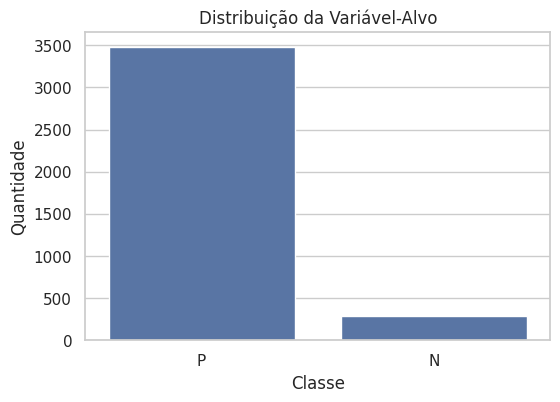

In [21]:
# Gráfico da distribuição da variável-alvo
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x='binaryClass')
plt.title('Distribuição da Variável-Alvo')
plt.xlabel('Classe')
plt.ylabel('Quantidade')
plt.show()

A variável-alvo apresenta forte desbalanceamento entre as classes. A classe P possui 3.481 registros, representando aproximadamente 92,28% da base, enquanto a classe N possui 291 registros, cerca de 7,71%.

Esse desbalanceamento é relevante porque um modelo pode alcançar alta acurácia apenas ao favorecer a classe majoritária. Por isso, a avaliação do modelo não será baseada apenas na acurácia. Serão consideradas também métricas como precisão, recall, F1-score e matriz de confusão, com atenção especial ao desempenho na classe minoritária.

In [22]:
# Estatísticas descritivas das variáveis numéricas
df_clean[numeric_cols].describe()

,age,TSH,T3,TT4,T4U,FTI
count,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000
mean,51.630170,4.726104,2.010748,107.993584,0.993461,110.115509
std,18.978034,23.316598,0.738282,34.520088,0.185212,31.372681
min,1.000000,0.005000,0.050000,2.000000,0.250000,2.000000
25%,36.000000,0.600000,1.700000,89.000000,0.890000,94.000000
50%,54.000000,1.400000,2.000000,103.000000,0.980000,107.000000
75%,67.000000,2.425000,2.200000,123.000000,1.070000,121.250000
max,94.000000,530.000000,10.600000,430.000000,2.320000,395.000000


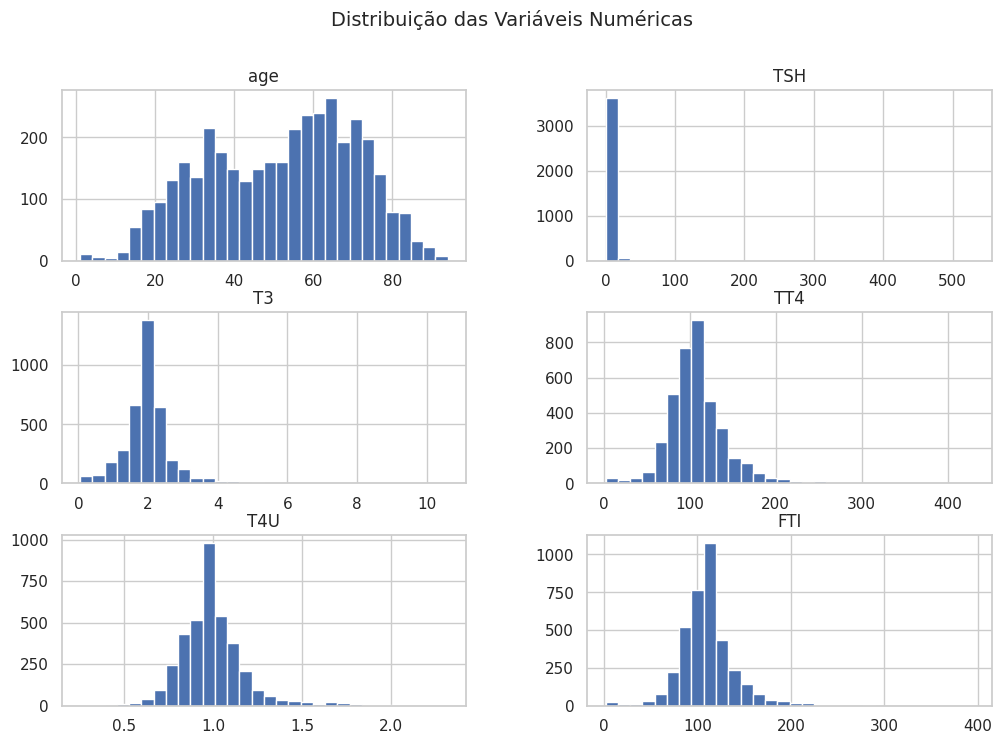

In [23]:
# Histogramas das variáveis numéricas
df_clean[numeric_cols].hist(figsize=(12, 8), bins=30)
plt.suptitle('Distribuição das Variáveis Numéricas', fontsize=14)
plt.show()

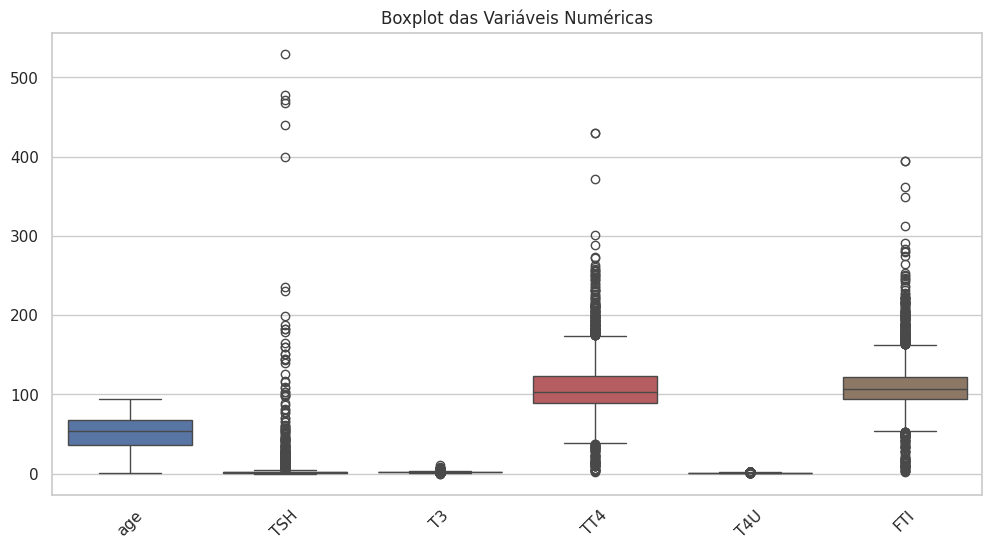

In [24]:
# Boxplots das variáveis numéricas
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean[numeric_cols])
plt.title('Boxplot das Variáveis Numéricas')
plt.xticks(rotation=45)
plt.show()

As variáveis numéricas apresentam diferentes escalas e distribuições, especialmente os exames laboratoriais. Após o tratamento do valor inconsistente na variável idade, ainda é possível observar possíveis outliers em exames como TSH, TT4 e FTI. A presença desses valores reforça a escolha da mediana para tratamento de ausentes e indica que a padronização poderá ser útil para modelos sensíveis à escala, como Regressão Logística e SVM.

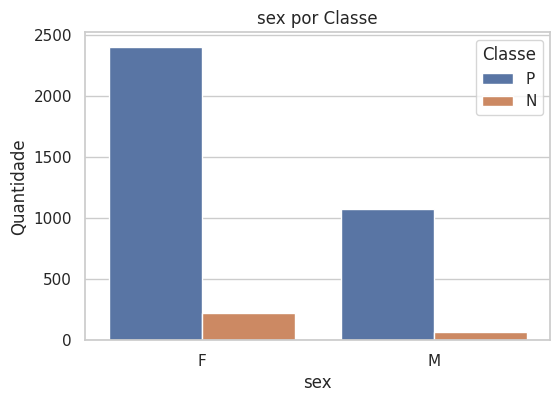

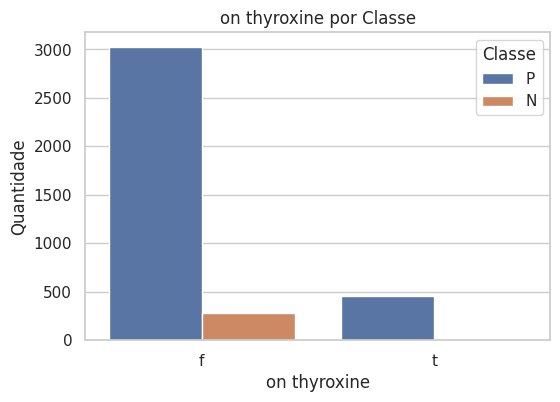

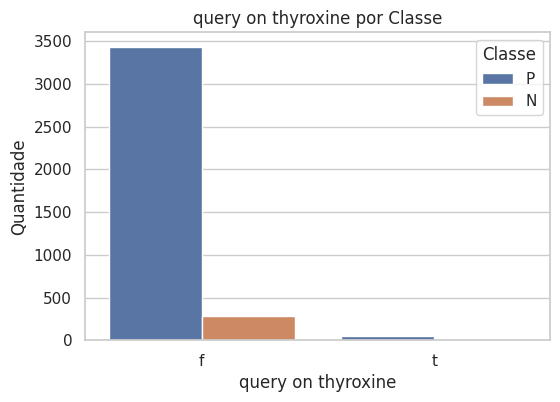

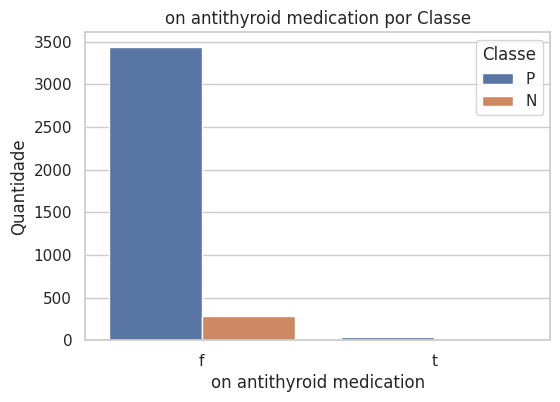

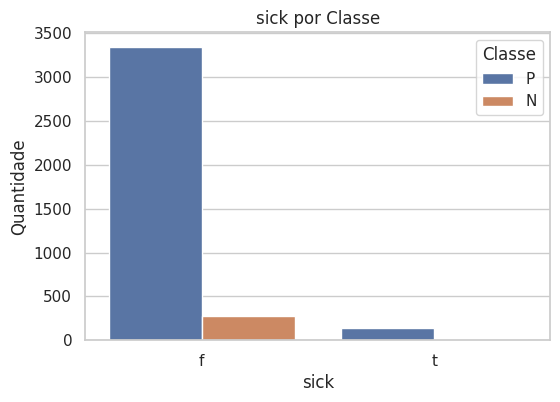

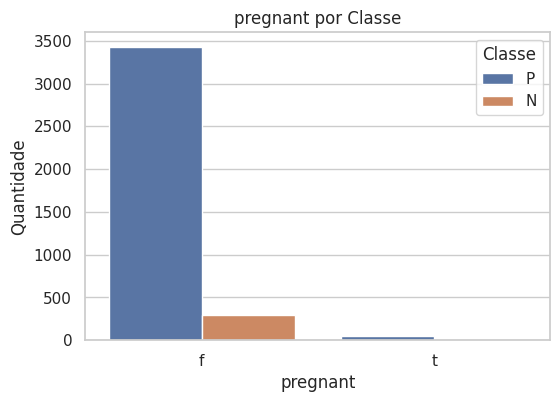

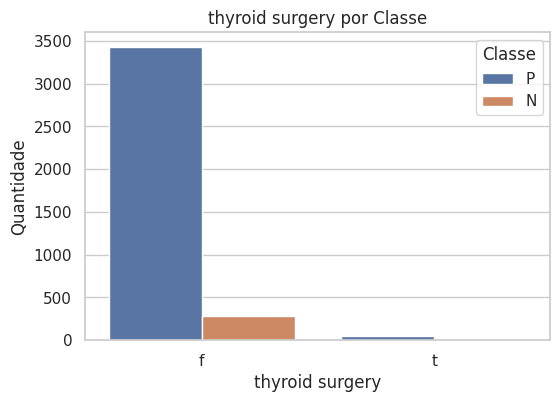

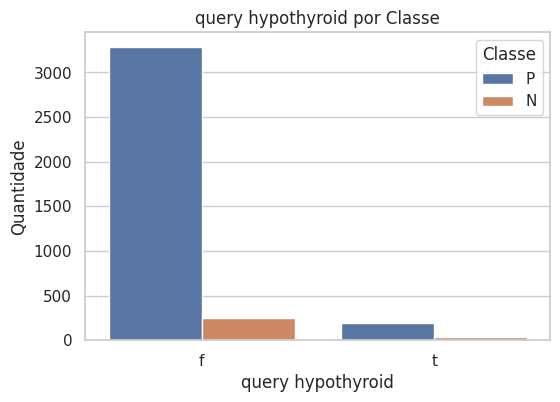

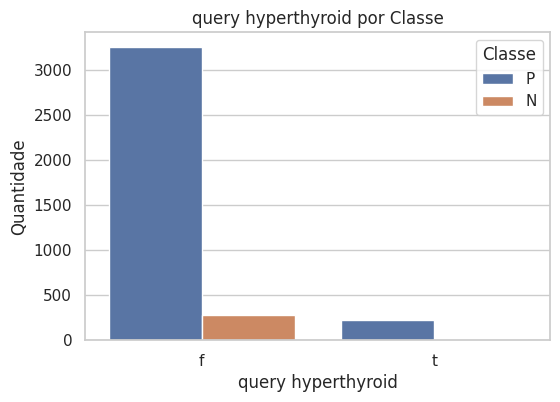

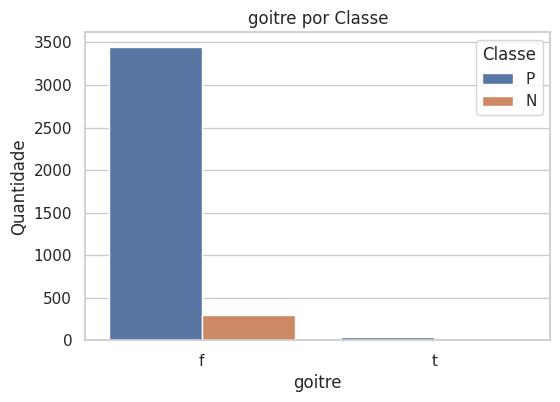

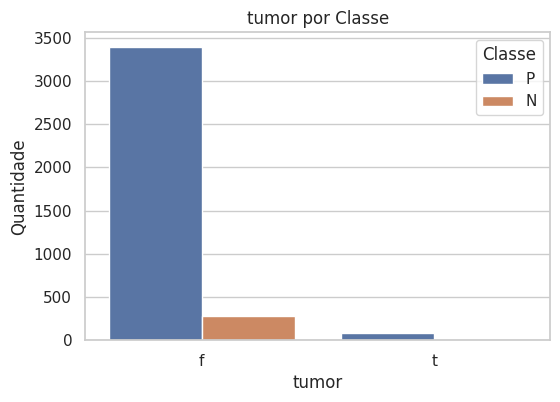

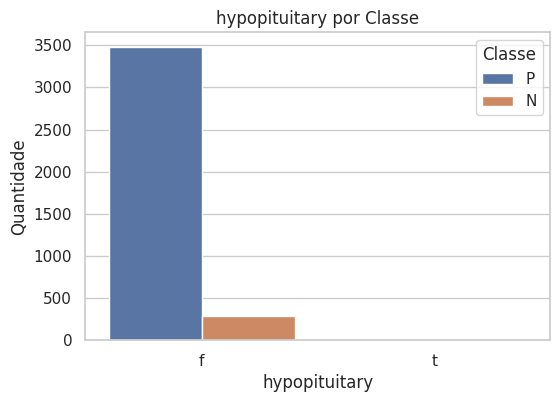

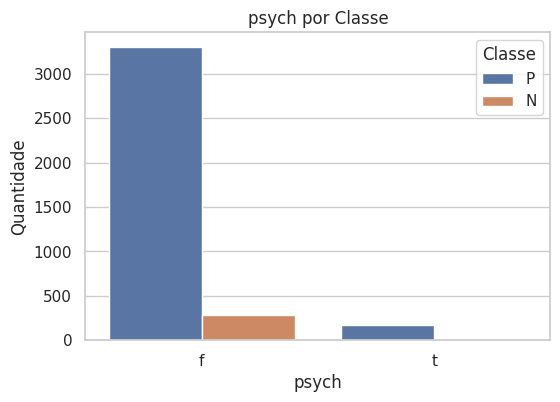

In [25]:
# Lista de variáveis categóricas para análise
categorical_analysis = [
    'sex',
    'on thyroxine',
    'query on thyroxine',
    'on antithyroid medication',
    'sick',
    'pregnant',
    'thyroid surgery',
    'query hypothyroid',
    'query hyperthyroid',
    'goitre',
    'tumor',
    'hypopituitary',
    'psych'
]

for col in categorical_analysis:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df_clean, x=col, hue='binaryClass')
    plt.title(f'{col} por Classe')
    plt.xlabel(col)
    plt.ylabel('Quantidade')
    plt.legend(title='Classe')
    plt.show()

A análise das variáveis categóricas permite observar a relação entre histórico médico, sintomas, uso de medicamentos e a classificação final. Algumas variáveis podem apresentar maior concentração em determinada classe, contribuindo para o aprendizado dos modelos.

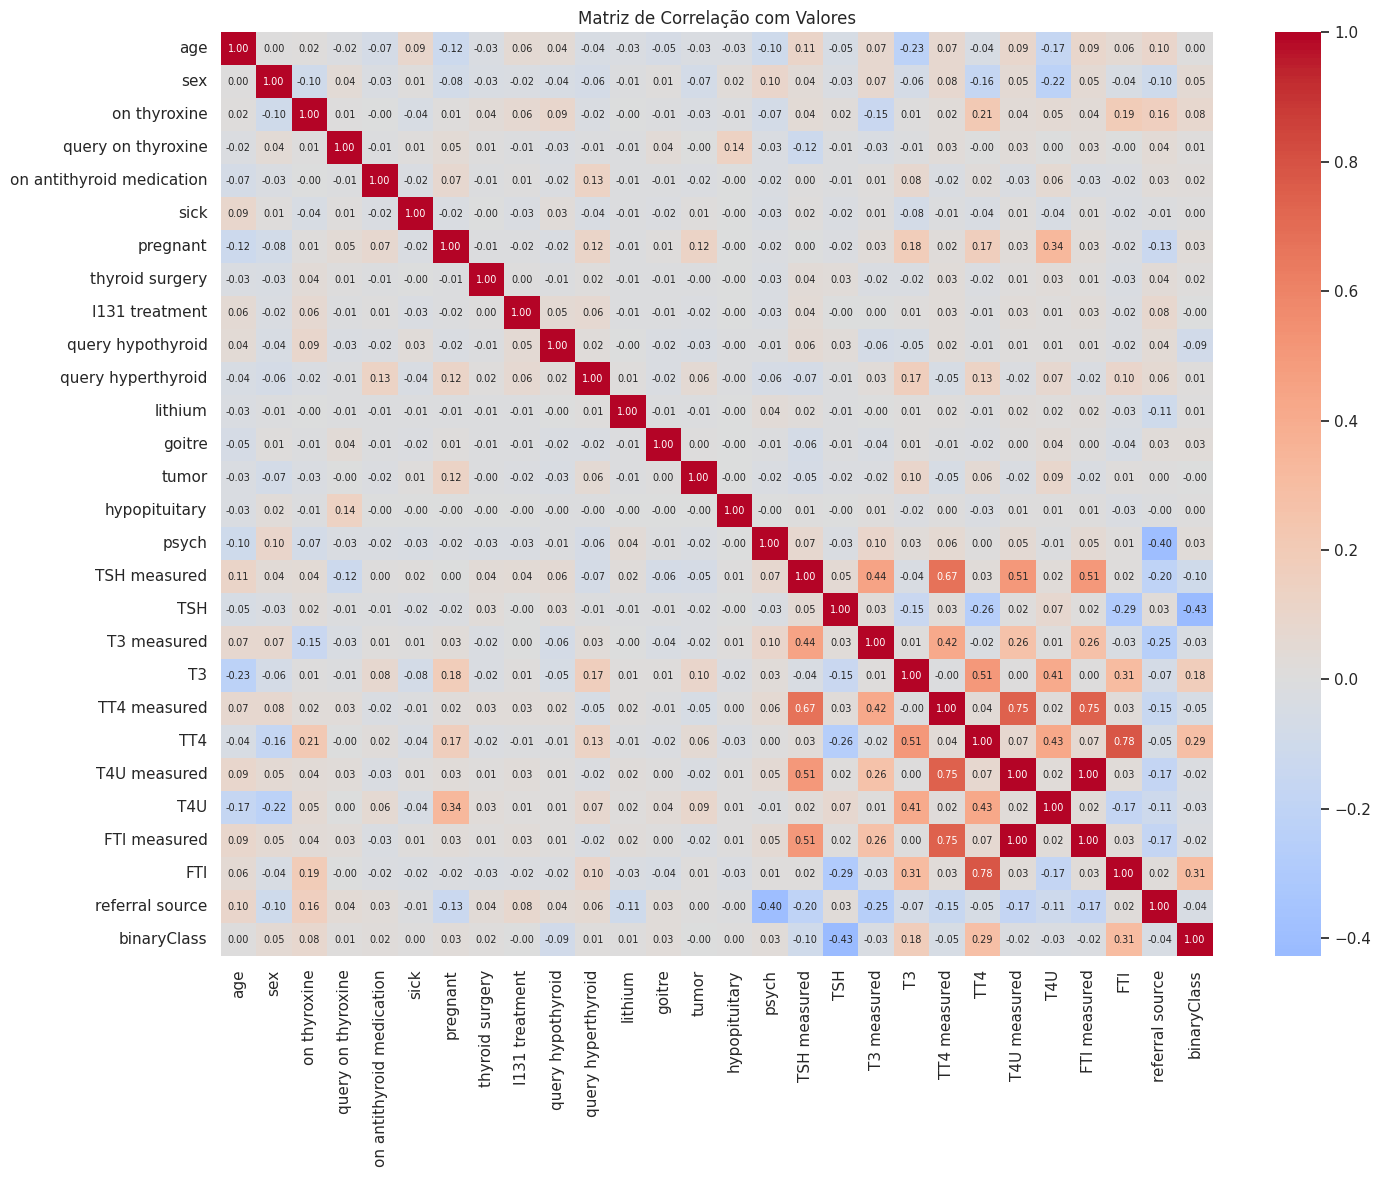

In [26]:
# Criando uma cópia para análise de correlação
df_corr = df_clean.copy()

# Convertendo variáveis categóricas para códigos numéricos apenas para análise de correlação
for col in df_corr.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_corr[col] = le.fit_transform(df_corr[col])

# Removendo colunas constantes, pois não geram correlação útil
constant_cols = [col for col in df_corr.columns if df_corr[col].nunique() <= 1]
df_corr = df_corr.drop(columns=constant_cols)

# Calculando a matriz de correlação
corr = df_corr.corr()

# Matriz de correlação com valores
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7}
)

plt.title('Matriz de Correlação com Valores')
plt.show()

In [27]:
# Correlação das variáveis com a variável-alvo, removendo valores NaN
corr_target = (
    corr['binaryClass']
    .drop('binaryClass')
    .dropna()
    .sort_values(key=abs, ascending=False)
)

corr_target

TSH                         -0.427963
FTI                          0.313098
TT4                          0.289514
T3                           0.177436
TSH measured                -0.095209
query hypothyroid           -0.086282
on thyroxine                 0.081060
TT4 measured                -0.053129
sex                          0.049960
referral source             -0.041571
pregnant                     0.034516
T3 measured                 -0.032866
T4U                         -0.028720
psych                        0.028575
goitre                       0.027575
on antithyroid medication    0.021689
thyroid surgery              0.017633
T4U measured                -0.015901
FTI measured                -0.015431
query hyperthyroid           0.013446
query on thyroxine           0.007448
lithium                      0.005603
hypopituitary                0.004708
tumor                       -0.003747
I131 treatment              -0.003590
sick                         0.001749
age         

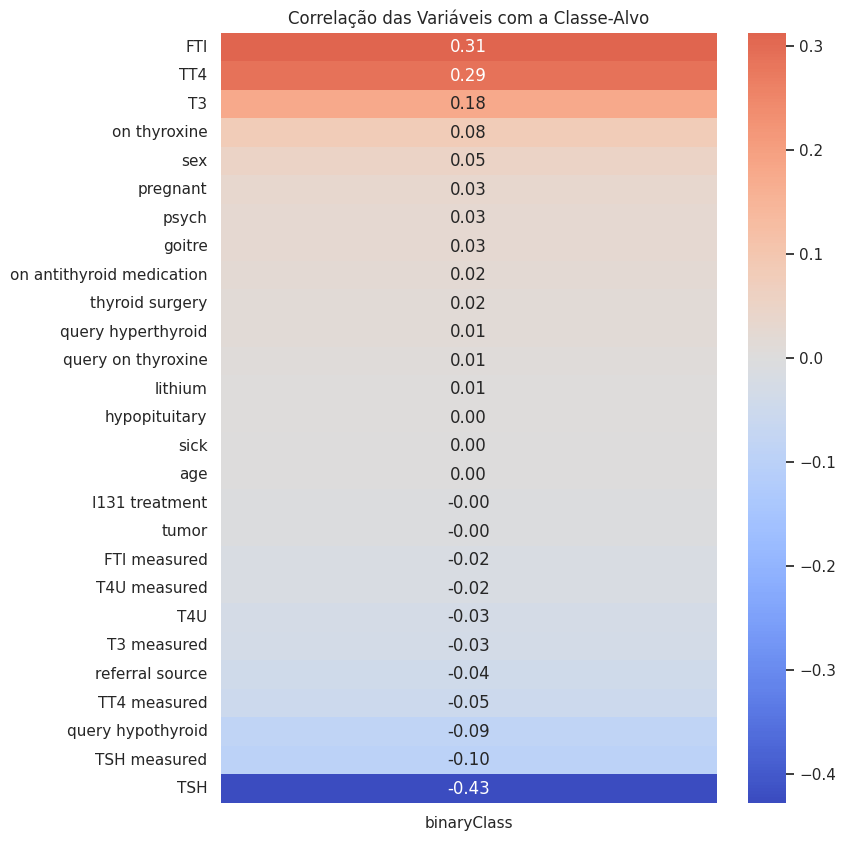

In [28]:
# Visualizando as correlações com a variável-alvo
corr_target_df = corr[['binaryClass']].drop('binaryClass').dropna()

plt.figure(figsize=(8, 10))

sns.heatmap(
    corr_target_df.sort_values(by='binaryClass', ascending=False),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlação das Variáveis com a Classe-Alvo')
plt.show()

A matriz de correlação com valores permite observar de forma mais detalhada as relações entre as variáveis. No entanto, como a base possui muitas colunas, a visualização pode ficar carregada. Por isso, também foi analisada a correlação das variáveis diretamente com a classe-alvo, facilitando a identificação dos atributos mais associados ao diagnóstico.

Observa-se que algumas variáveis laboratoriais, como TSH, FTI, TT4 e T3, apresentam maior relação com a variável-alvo. O TSH apresentou a maior correlação em módulo, indicando que esse exame pode ter papel importante na classificação realizada pelos modelos.

A análise das variáveis categóricas mostra que a maioria dos registros está concentrada na categoria "f" para diversas condições clínicas e tratamentos. Também é possível observar o efeito do desbalanceamento da variável-alvo, já que a classe P aparece em maior quantidade em praticamente todos os gráficos. Ainda assim, essas variáveis podem contribuir para o modelo ao representar histórico médico, sintomas e informações relacionadas ao tratamento dos pacientes.

## 8. Pré-processamento para Modelagem

In [29]:
# Criando uma cópia da base tratada para modelagem
df_model = df_clean.copy()

# Separando variáveis explicativas e variável-alvo
X = df_model.drop(columns=['binaryClass'])
y = df_model['binaryClass']

In [30]:
# Codificando variáveis categóricas com One-Hot Encoding
X = pd.get_dummies(X, drop_first=True, dtype=int)

# Visualizando a base após codificação
X.head()

,age,TSH,T3,TT4,T4U,FTI,sex_M,on thyroxine_t,query on thyroxine_t,on antithyroid medication_t,sick_t,pregnant_t,thyroid surgery_t,I131 treatment_t,query hypothyroid_t,query hyperthyroid_t,lithium_t,goitre_t,tumor_t,hypopituitary_t,psych_t,TSH measured_t,T3 measured_t,TT4 measured_t,T4U measured_t,FTI measured_t,referral source_SVHC,referral source_SVHD,referral source_SVI,referral source_other
0,41.0,1.30,2.5,125.0,1.14,109.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,0,0,0
1,23.0,4.10,2.0,102.0,0.98,107.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,1
2,46.0,0.98,2.0,109.0,0.91,120.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,1,0,0,0,1
3,70.0,0.16,1.9,175.0,0.98,107.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,1
4,70.0,0.72,1.2,61.0,0.87,70.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,0,0,1,0


In [31]:
# Verificando o formato da base após o pré-processamento
X.shape

(3772, 30)

In [32]:
# Verificando a distribuição da variável-alvo
y.value_counts(normalize=True) * 100

binaryClass
P    92.28526
N     7.71474
Name: proportion, dtype: float64

Nesta etapa, a variável-alvo foi separada das variáveis explicativas. As variáveis categóricas foram transformadas em variáveis numéricas por meio da técnica One-Hot Encoding, permitindo que sejam utilizadas pelos algoritmos de Machine Learning.

Como a variável-alvo apresenta desbalanceamento entre as classes, a divisão entre treino e teste foi realizada de forma estratificada. Essa técnica preserva a proporção das classes nos dois conjuntos, permitindo uma avaliação mais representativa do desempenho do modelo.

## 9. Divisão entre Treino e Teste

In [33]:
# Dividindo a base em treino e teste com estratificação da variável-alvo
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [34]:
# Verificando as dimensões dos conjuntos
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (3017, 30)
X_test: (755, 30)
y_train: (3017,)
y_test: (755,)


In [35]:
# Verificando a proporção das classes no treino
y_train.value_counts(normalize=True) * 100

binaryClass
P    92.277096
N     7.722904
Name: proportion, dtype: float64

In [36]:
# Verificando a proporção das classes no teste
y_test.value_counts(normalize=True) * 100

binaryClass
P    92.317881
N     7.682119
Name: proportion, dtype: float64

A divisão dos dados foi realizada utilizando estratificação, garantindo que a proporção das classes fosse mantida nos conjuntos de treino e teste. Essa decisão é importante devido ao desbalanceamento identificado na variável-alvo.

## 10. Treinamento dos Modelos

In [37]:
# Padronizando os dados para modelos sensíveis à escala
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
# Definindo os modelos de classificação
modelos = {
    'Regressão Logística': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Árvore de Decisão': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'SVM': SVC(class_weight='balanced', probability=True, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

In [39]:
# Treinando e avaliando os modelos
resultados = []

for nome, modelo in modelos.items():
    
    if nome in ['Regressão Logística', 'SVM']:
        modelo.fit(X_train_scaled, y_train)
        y_pred = modelo.predict(X_test_scaled)
    else:
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)
    
    resultados.append({
        'Modelo': nome,
        'Acurácia': accuracy_score(y_test, y_pred),
        'Precisão Macro': precision_score(y_test, y_pred, average='macro'),
        'Recall Macro': recall_score(y_test, y_pred, average='macro'),
        'F1-score Macro': f1_score(y_test, y_pred, average='macro'),
        'Precisão Weighted': precision_score(y_test, y_pred, average='weighted'),
        'Recall Weighted': recall_score(y_test, y_pred, average='weighted'),
        'F1-score Weighted': f1_score(y_test, y_pred, average='weighted')
    })

df_resultados = pd.DataFrame(resultados)
df_resultados.sort_values(by='F1-score Macro', ascending=False)

,Modelo,Acurácia,Precisão Macro,Recall Macro,F1-score Macro,Precisão Weighted,Recall Weighted,F1-score Weighted
4,Gradient Boosting,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,Random Forest,0.998675,0.991525,0.999283,0.995368,0.998698,0.998675,0.998681
1,Árvore de Decisão,0.997351,0.983333,0.998565,0.990807,0.997439,0.997351,0.997372
0,Regressão Logística,0.977483,0.892904,0.971998,0.927954,0.981071,0.977483,0.978512
3,SVM,0.952318,0.815741,0.903045,0.852590,0.960472,0.952318,0.955209


Foram treinados diferentes modelos de classificação para comparar seus desempenhos na previsão da variável-alvo. Como a base apresenta desbalanceamento entre as classes, a análise não foi baseada apenas na acurácia. Também foram consideradas métricas como precisão, recall e F1-score macro, que avaliam o desempenho de forma mais equilibrada entre as classes.

O Gradient Boosting apresentou o melhor desempenho inicial, alcançando 100% nas métricas avaliadas. O Random Forest e a Árvore de Decisão também apresentaram resultados elevados. Como o desempenho do Gradient Boosting foi perfeito no conjunto de teste, será realizada uma avaliação mais detalhada para verificar a consistência do modelo.

## 11. Avaliação dos Modelos

In [40]:
# Visualizando os resultados ordenados pelo F1-score Macro
df_resultados.sort_values(by='F1-score Macro', ascending=False)

,Modelo,Acurácia,Precisão Macro,Recall Macro,F1-score Macro,Precisão Weighted,Recall Weighted,F1-score Weighted
4,Gradient Boosting,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,Random Forest,0.998675,0.991525,0.999283,0.995368,0.998698,0.998675,0.998681
1,Árvore de Decisão,0.997351,0.983333,0.998565,0.990807,0.997439,0.997351,0.997372
0,Regressão Logística,0.977483,0.892904,0.971998,0.927954,0.981071,0.977483,0.978512
3,SVM,0.952318,0.815741,0.903045,0.852590,0.960472,0.952318,0.955209


Os resultados iniciais mostram que o modelo Gradient Boosting apresentou o melhor desempenho entre os modelos avaliados, alcançando 100% em todas as métricas consideradas. O Random Forest também apresentou desempenho muito elevado, seguido pela Árvore de Decisão.

Como a base possui forte desbalanceamento entre as classes, a escolha do melhor modelo não deve considerar apenas a acurácia. Por isso, foram analisadas também as métricas de precisão, recall e F1-score macro, que avaliam o desempenho considerando as classes de forma mais equilibrada.

In [41]:
# Treinando novamente o melhor modelo inicial
best_model = GradientBoostingClassifier(random_state=42)

best_model.fit(X_train, y_train)

# Predições no conjunto de teste
y_pred_best = best_model.predict(X_test)

In [42]:
# Relatório de classificação do melhor modelo
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           N       1.00      1.00      1.00        58
           P       1.00      1.00      1.00       697

    accuracy                           1.00       755
   macro avg       1.00      1.00      1.00       755
weighted avg       1.00      1.00      1.00       755



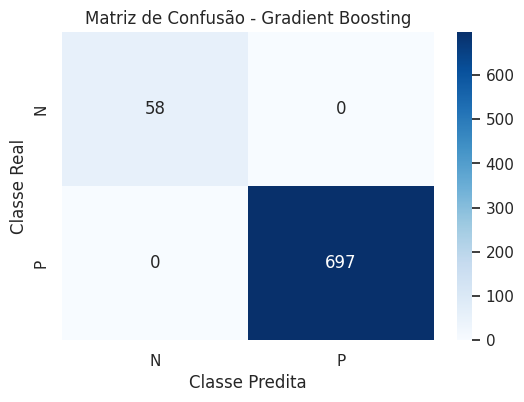

In [43]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_best, labels=best_model.classes_)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=best_model.classes_,
    yticklabels=best_model.classes_
)

plt.title('Matriz de Confusão - Gradient Boosting')
plt.xlabel('Classe Predita')
plt.ylabel('Classe Real')
plt.show()

A matriz de confusão permite observar de forma mais detalhada os acertos e erros do modelo em cada classe. Como o Gradient Boosting apresentou desempenho perfeito no conjunto de teste, não foram identificados erros de classificação nessa divisão específica dos dados.

Apesar do resultado ser muito positivo, é importante realizar uma validação adicional, pois resultados perfeitos podem indicar que o problema é altamente separável, mas também podem sugerir risco de sobreajuste ou presença de variáveis muito associadas à classe-alvo.

In [44]:
# Validação cruzada do melhor modelo
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro',
    'f1_macro': 'f1_macro'
}

cv_results = cross_validate(
    GradientBoostingClassifier(random_state=42),
    X,
    y,
    cv=cv,
    scoring=scoring
)

df_cv = pd.DataFrame({
    'Métrica': ['Acurácia', 'Precisão Macro', 'Recall Macro', 'F1-score Macro'],
    'Média': [
        cv_results['test_accuracy'].mean(),
        cv_results['test_precision_macro'].mean(),
        cv_results['test_recall_macro'].mean(),
        cv_results['test_f1_macro'].mean()
    ],
    'Desvio Padrão': [
        cv_results['test_accuracy'].std(),
        cv_results['test_precision_macro'].std(),
        cv_results['test_recall_macro'].std(),
        cv_results['test_f1_macro'].std()
    ]
})

df_cv

,Métrica,Média,Desvio Padrão
0,Acurácia,0.996552,0.001985
1,Precisão Macro,0.981561,0.010696
2,Recall Macro,0.994972,0.006891
3,F1-score Macro,0.988067,0.006879


A validação cruzada foi utilizada para verificar se o desempenho do modelo se mantém consistente em diferentes divisões da base. Essa etapa é importante para avaliar a capacidade de generalização do modelo e reduzir o risco de que o bom desempenho esteja associado apenas a uma divisão específica entre treino e teste.

## 12. Ajuste e Escolha do Modelo Final

In [45]:
# Ajuste de hiperparâmetros para o Gradient Boosting

param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3, 4]
}

grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

grid_search.best_params_

{'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 50}

In [46]:
# Melhor modelo após ajuste
final_model = grid_search.best_estimator_

# Predições com o modelo final
y_pred_final = final_model.predict(X_test)

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           N       0.97      0.98      0.97        58
           P       1.00      1.00      1.00       697

    accuracy                           1.00       755
   macro avg       0.98      0.99      0.99       755
weighted avg       1.00      1.00      1.00       755



In [47]:
# Métricas finais do modelo escolhido
final_metrics = pd.DataFrame({
    'Modelo': ['Gradient Boosting Ajustado'],
    'Acurácia': [accuracy_score(y_test, y_pred_final)],
    'Precisão Macro': [precision_score(y_test, y_pred_final, average='macro')],
    'Recall Macro': [recall_score(y_test, y_pred_final, average='macro')],
    'F1-score Macro': [f1_score(y_test, y_pred_final, average='macro')],
    'Precisão Weighted': [precision_score(y_test, y_pred_final, average='weighted')],
    'Recall Weighted': [recall_score(y_test, y_pred_final, average='weighted')],
    'F1-score Weighted': [f1_score(y_test, y_pred_final, average='weighted')]
})

final_metrics

,Modelo,Acurácia,Precisão Macro,Recall Macro,F1-score Macro,Precisão Weighted,Recall Weighted,F1-score Weighted
0,Gradient Boosting Ajustado,0.996026,0.982332,0.989945,0.986103,0.996069,0.996026,0.996042


Após o ajuste de hiperparâmetros, o modelo final escolhido foi o Gradient Boosting com learning_rate = 0.05, max_depth = 4 e n_estimators = 50.

O modelo apresentou desempenho elevado no conjunto de teste, com acurácia de aproximadamente 99,60%, F1-score macro de 98,61% e recall macro de 98,99%. Esses resultados indicam boa capacidade de classificação, inclusive considerando o desbalanceamento da variável-alvo.

A escolha foi baseada principalmente no F1-score macro, pois essa métrica considera o desempenho das classes de forma equilibrada, sendo mais adequada para bases desbalanceadas. Como o problema envolve apoio ao diagnóstico clínico, também foram consideradas métricas como precisão, recall e matriz de confusão.

## 13. Interpretação dos Resultados

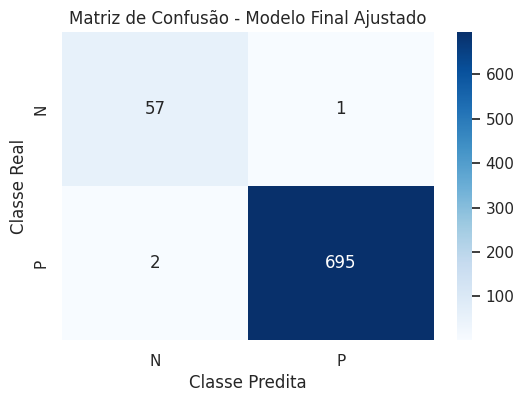

In [48]:
# Matriz de confusão do modelo final ajustado
cm_final = confusion_matrix(y_test, y_pred_final, labels=final_model.classes_)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_final,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=final_model.classes_,
    yticklabels=final_model.classes_
)

plt.title('Matriz de Confusão - Modelo Final Ajustado')
plt.xlabel('Classe Predita')
plt.ylabel('Classe Real')
plt.show()

In [49]:
# Importância das variáveis no modelo final
feature_importance = pd.DataFrame({
    'Variável': X.columns,
    'Importância': final_model.feature_importances_
}).sort_values(by='Importância', ascending=False)

feature_importance.head(15)

,Variável,Importância
1,TSH,0.765991
7,on thyroxine_t,0.113632
5,FTI,0.039966
3,TT4,0.039429
12,thyroid surgery_t,0.029140
4,T4U,0.004267
2,T3,0.004138
14,query hypothyroid_t,0.001641
29,referral source_other,0.000901
28,referral source_SVI,0.000603


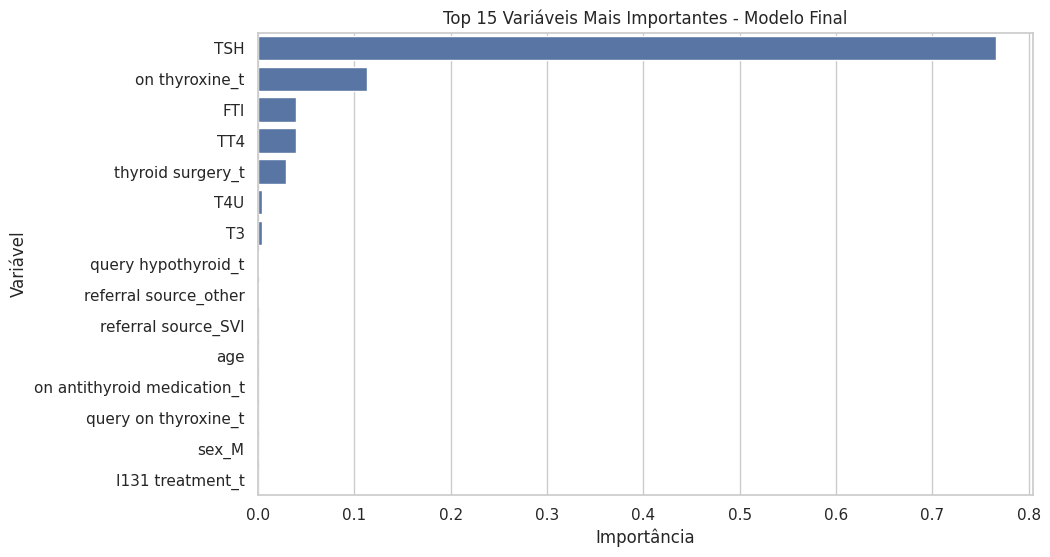

In [50]:
# Visualizando as 15 variáveis mais importantes
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x='Importância', y='Variável')
plt.title('Top 15 Variáveis Mais Importantes - Modelo Final')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.show()

A matriz de confusão mostra que o modelo final ajustado apresentou apenas 3 erros em 755 registros do conjunto de teste. Foram classificados corretamente 57 casos da classe N e 695 casos da classe P. O modelo errou 1 registro da classe N, classificando-o como P, e 2 registros da classe P, classificando-os como N.

Esse resultado indica alto desempenho preditivo, mesmo diante do desbalanceamento entre as classes. Ainda assim, por se tratar de um problema relacionado à área da saúde, é importante interpretar o modelo como uma ferramenta de apoio à decisão, e não como substituto da avaliação médica.

A análise de importância das variáveis mostra que o exame TSH foi o principal atributo utilizado pelo modelo, com importância muito superior às demais variáveis. Também aparecem entre os atributos mais relevantes o uso de tiroxina, FTI, TT4, histórico de cirurgia da tireoide, T4U e T3. Esses resultados indicam que exames laboratoriais e informações clínicas relacionadas à tireoide tiveram papel importante na classificação.

## 14. Recomendações para o Stakeholder

Com base nos resultados obtidos, o modelo Gradient Boosting ajustado demonstrou alto desempenho na classificação dos registros relacionados a doenças da tireoide. O modelo apresentou acurácia de aproximadamente 99,60% e F1-score macro de aproximadamente 98,61%, indicando bom equilíbrio entre as classes, mesmo com a presença de desbalanceamento na variável-alvo.

Recomenda-se que o modelo seja utilizado como ferramenta de apoio à decisão clínica, e não como substituto da avaliação médica. Em um contexto real, seria necessário validar o modelo com novos dados, acompanhar seu desempenho ao longo do tempo e revisar periodicamente suas previsões.

Também é importante confirmar o significado clínico das classes P e N com o stakeholder ou com a documentação da base, garantindo que a interpretação dos resultados esteja alinhada ao diagnóstico correto.

## 15. Conclusão Final

O projeto teve como objetivo desenvolver uma solução de Machine Learning para apoiar o diagnóstico de doenças da tireoide a partir de dados clínicos, laboratoriais e históricos dos pacientes. Para isso, foram realizadas etapas de entendimento do problema, análise inicial da base, tratamento de valores ausentes, transformação de variáveis, análise exploratória, treinamento e avaliação de diferentes modelos de classificação.

Durante a análise, foi identificado um forte desbalanceamento na variável-alvo, com predominância da classe P. Por esse motivo, a avaliação dos modelos considerou não apenas a acurácia, mas também precisão, recall e F1-score macro.

Entre os modelos avaliados, o Gradient Boosting apresentou o melhor desempenho geral. Após o ajuste de hiperparâmetros, o modelo final manteve resultados elevados, com acurácia aproximada de 99,60% e F1-score macro de 98,61%. Esses resultados indicam que o modelo possui boa capacidade preditiva e pode contribuir como ferramenta de apoio à análise clínica.

Apesar do bom desempenho, é importante destacar que modelos aplicados à área da saúde devem passar por validações adicionais antes de uso em ambiente real. Portanto, a solução desenvolvida deve ser interpretada como um apoio à tomada de decisão, sempre acompanhada da avaliação de profissionais especializados.

Portanto, o projeto cumpriu o objetivo proposto ao desenvolver uma solução completa de Ciência de Dados, passando pelas etapas de preparação dos dados, análise exploratória, modelagem, avaliação e comunicação dos resultados. O modelo final apresentou desempenho elevado e interpretável, mas sua aplicação prática exigiria validação adicional em ambiente clínico real.